# Лабораторна робота №2: Логістична регресія та федеративне навчання
## Етап 1. Дослідження даних та попередня обробка

**Обґрунтування вибору ознак та Data Leakage:**
У датасеті Dry Bean усі числові ознаки описують фізичні параметри зерен. Ми залишаємо їх усі, оскільки вони є інформативними. 
**Data Leakage (витік даних)** — це ситуація, коли інформація з тестової вибірки впливає на навчання моделі. Щоб цього уникнути, ми спочатку розбиваємо дані на Train, Validation та Test. Масштабування (`StandardScaler`) ми "навчаємо" (`fit`) виключно на тренувальних даних, а до тестових лише застосовуємо вже розраховані параметри (`transform`).

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Читаємо Excel файл. Вказуємо конкретну сторінку з даними.
# Якщо видасть помилку, спробуй sheet_name=1 або sheet_name=0
df = pd.read_excel('Dry_Bean_Dataset.xlsx', sheet_name='Dry_Beans_Dataset')

# Відокремлюємо X та y
X = df.drop('Class', axis=1)
y_labels = df['Class']

# Кодуємо класи у числа (0-6)
encoder = LabelEncoder()
y = encoder.fit_transform(y_labels)

# 1. Відділяємо Global Test (15%)
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.15, stratify=y, random_state=42)

# 2. Відділяємо Global Validation (ще 15% від початкового розміру)
X_train_fl, X_val, y_train_fl, y_val = train_test_split(X_temp, y_temp, test_size=0.1765, stratify=y_temp, random_state=42)

print(f"FL Train Pool (для клієнтів): {X_train_fl.shape}")
print(f"Global Validation (для сервера): {X_val.shape}")
print(f"Global Test (для фінальної оцінки): {X_test.shape}")

# 3. Правильне масштабування
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_fl) # Вчимо тільки на Train
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

FL Train Pool (для клієнтів): (9527, 16)
Global Validation (для сервера): (2042, 16)
Global Test (для фінальної оцінки): (2042, 16)


## Етап 2. Реалізація багатокласової логістичної регресії засобами NumPy
Ми реалізуємо модель без використання циклів `for` для обчислення градієнтів, покладаючись на векторизацію `numpy`. Використовується функція `softmax` із відніманням максимуму для числової стабільності та крос-ентропія з Ridge-регуляризацією.

In [17]:
class MultinomialLogisticRegression:
    def __init__(self, learning_rate=0.01, epochs=100, batch_size=32, lambda_reg=0.01):
        self.lr = learning_rate
        self.epochs = epochs
        self.batch_size = batch_size
        self.lambda_reg = lambda_reg
        self.W = None
        self.b = None
        
    def _one_hot(self, y, num_classes):
        m = len(y)
        one_hot = np.zeros((m, num_classes))
        one_hot[np.arange(m), y] = 1
        return one_hot
        
    def _softmax(self, Z):
        exp_Z = np.exp(Z - np.max(Z, axis=1, keepdims=True))
        return exp_Z / np.sum(exp_Z, axis=1, keepdims=True)
        
    def fit(self, X, y, num_classes=None):
        m, d = X.shape
        if num_classes is None:
            num_classes = len(np.unique(y))
            
        if self.W is None:
            self.W = np.zeros((d, num_classes))
            self.b = np.zeros((1, num_classes))
            
        Y_one_hot = self._one_hot(y, num_classes)
        
        for epoch in range(self.epochs):
            indices = np.random.permutation(m)
            X_shuf = X[indices]
            Y_shuf = Y_one_hot[indices]
            
            for i in range(0, m, self.batch_size):
                X_batch = X_shuf[i:i+self.batch_size]
                Y_batch = Y_shuf[i:i+self.batch_size]
                batch_size_actual = X_batch.shape[0]
                
                Z = np.dot(X_batch, self.W) + self.b
                P = self._softmax(Z)
                
                # Градієнти (векторизовано)
                error = P - Y_batch
                dW = (1 / batch_size_actual) * np.dot(X_batch.T, error) + self.lambda_reg * self.W
                db = (1 / batch_size_actual) * np.sum(error, axis=0, keepdims=True)
                
                self.W -= self.lr * dW
                self.b -= self.lr * db
                
    def predict_proba(self, X):
        return self._softmax(np.dot(X, self.W) + self.b)
        
    def predict(self, X):
        return np.argmax(self.predict_proba(X), axis=1)

## Етап 3. Централізована модель (Базова лінія)
Ця модель навчається на всьому масиві даних `FL Train Pool` і слугуватиме еталоном для порівняння з федеративними моделями.

from sklearn.metrics import accuracy_score, f1_score, balanced_accuracy_score, log_loss, confusion_matrix

central_model = MultinomialLogisticRegression(learning_rate=0.1, epochs=150, batch_size=64, lambda_reg=0.01)
central_model.fit(X_train_scaled, y_train_fl)

y_pred_central = central_model.predict(X_test_scaled)

print("--- Централізована модель на Global Test ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_central):.4f}")
print(f"Macro-F1: {f1_score(y_test, y_pred_central, average='macro'):.4f}")
print(f"Balanced Accuracy: {balanced_accuracy_score(y_test, y_pred_central):.4f}")

plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred_central), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Centralized Model')
plt.show()

--- Централізована модель на Global Test ---
Accuracy: 0.9143
Macro-F1: 0.9277
Balanced Accuracy: 0.9254


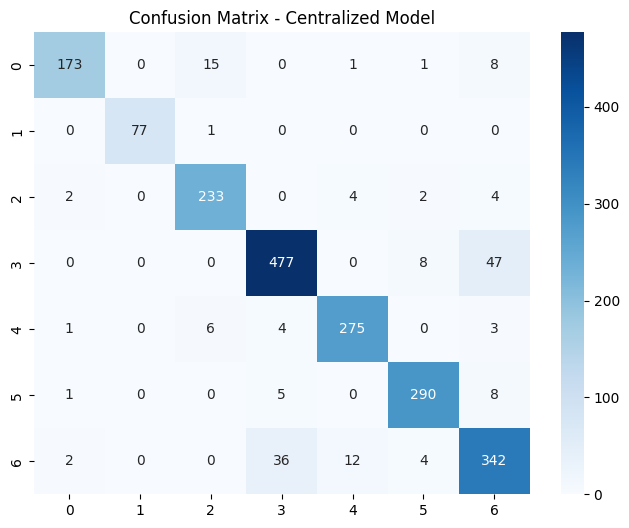

In [18]:
from sklearn.metrics import accuracy_score, f1_score, balanced_accuracy_score, log_loss, confusion_matrix

central_model = MultinomialLogisticRegression(learning_rate=0.1, epochs=150, batch_size=64, lambda_reg=0.01)
central_model.fit(X_train_scaled, y_train_fl)

y_pred_central = central_model.predict(X_test_scaled)

print("--- Централізована модель на Global Test ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_central):.4f}")
print(f"Macro-F1: {f1_score(y_test, y_pred_central, average='macro'):.4f}")
print(f"Balanced Accuracy: {balanced_accuracy_score(y_test, y_pred_central):.4f}")

plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred_central), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Centralized Model')
plt.show()

## Етап 4. Розподіл даних (Non-IID)
Симулюємо федеративне середовище з 5 клієнтами. Використовуємо розподіл Діріхле ($\alpha=0.5$), щоб змоделювати неоднорідність даних (коли у різних клієнтів різна кількість прикладів певних сортів квасолі).

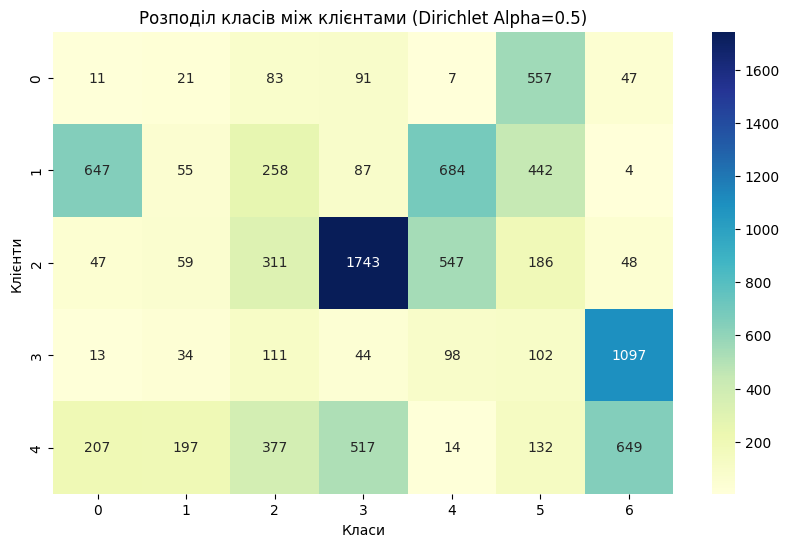

In [19]:
def distribute_data_dirichlet(X, y, num_clients, alpha=1.0):
    num_classes = len(np.unique(y))
    client_data = {i: {'X': [], 'y': []} for i in range(num_clients)}
    
    for c in range(num_classes):
        idx_c = np.where(y == c)[0]
        np.random.shuffle(idx_c)
        proportions = np.random.dirichlet(np.repeat(alpha, num_clients))
        splits = np.round(proportions * len(idx_c)).astype(int)
        splits[-1] = len(idx_c) - np.sum(splits[:-1]) 
        
        ptr = 0
        for i in range(num_clients):
            if splits[i] > 0:
                client_idx = idx_c[ptr:ptr+splits[i]]
                client_data[i]['X'].append(X[client_idx])
                client_data[i]['y'].append(y[client_idx])
                ptr += splits[i]
                
    for i in range(num_clients):
        if len(client_data[i]['X']) > 0:
            client_data[i]['X'] = np.vstack(client_data[i]['X'])
            client_data[i]['y'] = np.concatenate(client_data[i]['y'])
    return client_data

num_clients = 5
clients_data = distribute_data_dirichlet(X_train_scaled, y_train_fl, num_clients, alpha=0.5)

# Візуалізація
dist_matrix = np.zeros((num_clients, len(np.unique(y_train_fl))))
for i in range(num_clients):
    counts = np.bincount(clients_data[i]['y'], minlength=len(np.unique(y_train_fl)))
    dist_matrix[i, :] = counts

plt.figure(figsize=(10, 6))
sns.heatmap(dist_matrix, annot=True, fmt='g', cmap='YlGnBu')
plt.title('Розподіл класів між клієнтами (Dirichlet Alpha=0.5)')
plt.xlabel('Класи')
plt.ylabel('Клієнти')
plt.show()

## Етап 5. Симуляція FedAvg
Алгоритм Федеративного усереднення. Клієнти навчають моделі локально, після чого сервер агрегує їхні ваги, зважаючи на розмір локальної вибірки кожного клієнта.

In [20]:
def federated_averaging(global_model, client_models, client_sizes):
    total_samples = sum(client_sizes)
    new_W = np.zeros_like(global_model.W)
    new_b = np.zeros_like(global_model.b)
    
    for k, model in enumerate(client_models):
        weight = client_sizes[k] / total_samples
        new_W += weight * model.W
        new_b += weight * model.b
        
    global_model.W = new_W
    global_model.b = new_b
    return global_model

ROUNDS = 10
LOCAL_EPOCHS = 5
num_classes = len(np.unique(y_train_fl))

global_model = MultinomialLogisticRegression(learning_rate=0.1)
global_model.W = np.zeros((X_train_scaled.shape[1], num_classes))
global_model.b = np.zeros((1, num_classes))

for r in range(ROUNDS):
    client_models = []
    client_sizes = []
    
    for k in range(num_clients):
        X_k = clients_data[k]['X']
        y_k = clients_data[k]['y']
        
        if len(y_k) == 0: continue
            
        local_model = MultinomialLogisticRegression(learning_rate=0.1, epochs=LOCAL_EPOCHS, batch_size=32)
        local_model.W = np.copy(global_model.W)
        local_model.b = np.copy(global_model.b)
        local_model.fit(X_k, y_k, num_classes=num_classes)
        
        client_models.append(local_model)
        client_sizes.append(len(y_k))
        
    global_model = federated_averaging(global_model, client_models, client_sizes)
    val_acc = accuracy_score(y_val, global_model.predict(X_val_scaled))
    print(f"Раунд {r+1}/{ROUNDS} | Validation Accuracy: {val_acc:.4f}")

print("\n--- Глобальна Федеративна Модель (Global Test) ---")
print(f"Accuracy: {accuracy_score(y_test, global_model.predict(X_test_scaled)):.4f}")

Раунд 1/10 | Validation Accuracy: 0.8139
Раунд 2/10 | Validation Accuracy: 0.8746
Раунд 3/10 | Validation Accuracy: 0.8986
Раунд 4/10 | Validation Accuracy: 0.9016
Раунд 5/10 | Validation Accuracy: 0.9035
Раунд 6/10 | Validation Accuracy: 0.9030
Раунд 7/10 | Validation Accuracy: 0.9050
Раунд 8/10 | Validation Accuracy: 0.9074
Раунд 9/10 | Validation Accuracy: 0.9065
Раунд 10/10 | Validation Accuracy: 0.9040

--- Глобальна Федеративна Модель (Global Test) ---
Accuracy: 0.8893


## Етап 6. Дослідження ефектів федеративного навчання
В цьому розділі ми проведемо два обов'язкові експерименти: дослідимо вплив неоднорідності даних (параметр $\alpha$ Діріхле) та вплив кількості локальних епох (Е). Також побудуємо порівняльну таблицю моделей.

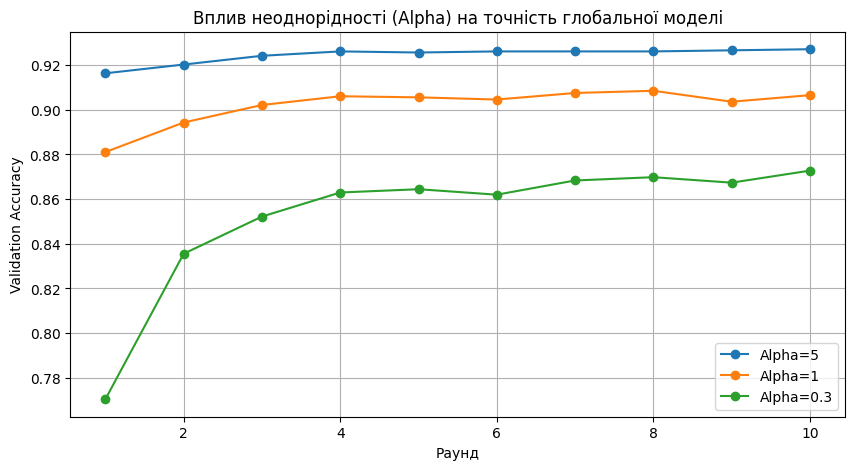

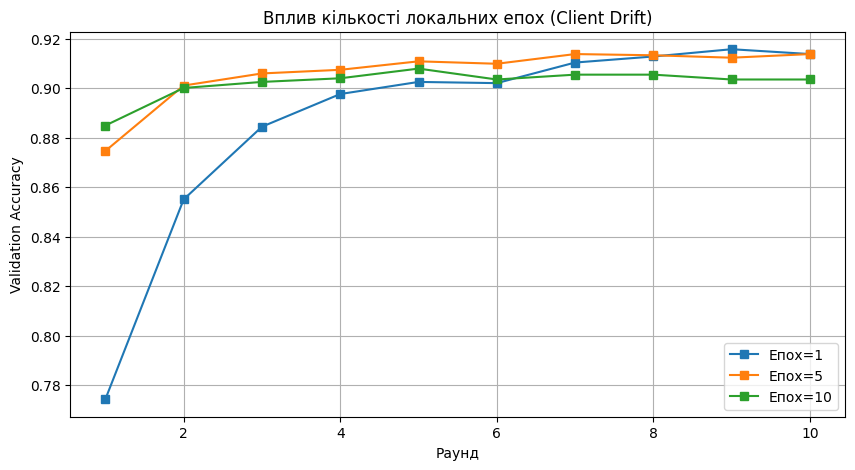


--- Порівняльна таблиця моделей на Global Test ---


,Model,Accuracy,Macro-F1,Balanced Acc,Log-Loss
0,Local Client 0,0.768854,0.776985,0.767892,0.551388
1,Global (FedAvg),0.896670,0.909689,0.900990,0.391741
2,Centralized,0.914300,0.927715,0.925385,0.313043


In [21]:
# ЕКСПЕРИМЕНТ 1: Вплив неоднорідності даних (Alpha)
alphas = [5, 1, 0.3]
alpha_acc_history = {}
final_alpha_acc = {}

for a in alphas:
    # Розподіл
    dist_data = distribute_data_dirichlet(X_train_scaled, y_train_fl, num_clients, alpha=a)
    
    # Ініціалізація моделі
    g_model = MultinomialLogisticRegression(learning_rate=0.1)
    g_model.W = np.zeros((X_train_scaled.shape[1], num_classes))
    g_model.b = np.zeros((1, num_classes))
    
    val_acc_trend = []
    
    for r in range(10): # 10 раундів
        c_models = []
        c_sizes = []
        for k in range(num_clients):
            if len(dist_data[k]['y']) == 0: continue
            l_model = MultinomialLogisticRegression(learning_rate=0.1, epochs=5, batch_size=32)
            l_model.W, l_model.b = np.copy(g_model.W), np.copy(g_model.b)
            l_model.fit(dist_data[k]['X'], dist_data[k]['y'], num_classes=num_classes)
            c_models.append(l_model)
            c_sizes.append(len(dist_data[k]['y']))
            
        g_model = federated_averaging(g_model, c_models, c_sizes)
        val_acc_trend.append(accuracy_score(y_val, g_model.predict(X_val_scaled)))
        
    alpha_acc_history[a] = val_acc_trend
    final_alpha_acc[a] = accuracy_score(y_test, g_model.predict(X_test_scaled))

# Графік для Експерименту 1
plt.figure(figsize=(10, 5))
for a in alphas:
    plt.plot(range(1, 11), alpha_acc_history[a], marker='o', label=f'Alpha={a}')
plt.title('Вплив неоднорідності (Alpha) на точність глобальної моделі')
plt.xlabel('Раунд')
plt.ylabel('Validation Accuracy')
plt.legend()
plt.grid()
plt.show()

# ЕКСПЕРИМЕНТ 2: Вплив кількості локальних епох (Е) на Non-IID даних (Alpha=0.3)
epochs_list = [1, 5, 10]
epoch_acc_history = {}
dist_data_e = distribute_data_dirichlet(X_train_scaled, y_train_fl, num_clients, alpha=0.3)

for e in epochs_list:
    g_model = MultinomialLogisticRegression(learning_rate=0.1)
    g_model.W = np.zeros((X_train_scaled.shape[1], num_classes))
    g_model.b = np.zeros((1, num_classes))
    val_acc_trend = []
    
    for r in range(10):
        c_models, c_sizes = [], []
        for k in range(num_clients):
            if len(dist_data_e[k]['y']) == 0: continue
            l_model = MultinomialLogisticRegression(learning_rate=0.1, epochs=e, batch_size=32)
            l_model.W, l_model.b = np.copy(g_model.W), np.copy(g_model.b)
            l_model.fit(dist_data_e[k]['X'], dist_data_e[k]['y'], num_classes=num_classes)
            c_models.append(l_model)
            c_sizes.append(len(dist_data_e[k]['y']))
            
        g_model = federated_averaging(g_model, c_models, c_sizes)
        val_acc_trend.append(accuracy_score(y_val, g_model.predict(X_val_scaled)))
    epoch_acc_history[e] = val_acc_trend

# Графік для Експерименту 2
plt.figure(figsize=(10, 5))
for e in epochs_list:
    plt.plot(range(1, 11), epoch_acc_history[e], marker='s', label=f'Епох={e}')
plt.title('Вплив кількості локальних епох (Client Drift)')
plt.xlabel('Раунд')
plt.ylabel('Validation Accuracy')
plt.legend()
plt.grid()
plt.show()

# ПОРІВНЯЛЬНА ТАБЛИЦЯ
# Візьмемо локальну модель клієнта 0 з останнього експерименту для порівняння
local_pred = c_models[0].predict(X_test_scaled)
local_proba = c_models[0].predict_proba(X_test_scaled)
global_pred = g_model.predict(X_test_scaled)
global_proba = g_model.predict_proba(X_test_scaled)

y_proba_central = central_model.predict_proba(X_test_scaled)

results = {
    "Model": ["Local Client 0", "Global (FedAvg)", "Centralized"],
    "Accuracy": [
        accuracy_score(y_test, local_pred),
        accuracy_score(y_test, global_pred),
        accuracy_score(y_test, y_pred_central)
    ],
    "Macro-F1": [
        f1_score(y_test, local_pred, average='macro'),
        f1_score(y_test, global_pred, average='macro'),
        f1_score(y_test, y_pred_central, average='macro')
    ],
    "Balanced Acc": [
        balanced_accuracy_score(y_test, local_pred),
        balanced_accuracy_score(y_test, global_pred),
        balanced_accuracy_score(y_test, y_pred_central)
    ],
    "Log-Loss": [
        log_loss(y_test, local_proba),
        log_loss(y_test, global_proba),
        log_loss(y_test, y_proba_central)
    ]
}

comparison_df = pd.DataFrame(results)
print("\n--- Порівняльна таблиця моделей на Global Test ---")
display(comparison_df)

## Етап 7. Додаткові експерименти (Персоналізація та вплив кількості клієнтів)
У цьому розділі ми виконаємо два додаткові експерименти, щоб глибше зрозуміти динаміку федеративного навчання:
1. **Експеримент А:** Дослідимо вплив кількості клієнтів ($K=3, 5, 10$) на якість глобальної моделі (наскільки швидко та ефективно збігається алгоритм при дробленні даних).
2. **Експеримент Б:** Перевіримо ефективність персоналізації — чи допоможе коротке локальне донавчання (1 епоха) загальної глобальної моделі на даних конкретного клієнта подолати наслідки клієнтського дрейфу на Non-IID даних.

In [22]:
# ==========================================
# Етап 7. Додаткові експерименти (Опційно)
# ==========================================
import numpy as np
from sklearn.metrics import accuracy_score

print("=== Експеримент А: Вплив кількості клієнтів ===")
k_list = [3, 5, 10]
k_results = {}

for k in k_list:
    # Розподіляємо дані на K клієнтів (з помірною неоднорідністю alpha=1.0)
    dist_data_k = distribute_data_dirichlet(X_train_scaled, y_train_fl, k, alpha=1.0)
    
    # Ініціалізуємо нову глобальну модель
    g_model_k = MultinomialLogisticRegression(learning_rate=0.1)
    g_model_k.W = np.zeros((X_train_scaled.shape[1], num_classes))
    g_model_k.b = np.zeros((1, num_classes))
    
    # Симулюємо 5 раундів
    for r in range(5): 
        c_models = []
        c_sizes = []
        for client_id in range(k):
            if len(dist_data_k[client_id]['y']) == 0: continue
            
            l_model = MultinomialLogisticRegression(learning_rate=0.1, epochs=3, batch_size=32)
            l_model.W = np.copy(g_model_k.W)
            l_model.b = np.copy(g_model_k.b)
            l_model.fit(dist_data_k[client_id]['X'], dist_data_k[client_id]['y'], num_classes=num_classes)
            
            c_models.append(l_model)
            c_sizes.append(len(dist_data_k[client_id]['y']))
            
        g_model_k = federated_averaging(g_model_k, c_models, c_sizes)
        
    acc = accuracy_score(y_test, g_model_k.predict(X_test_scaled))
    k_results[k] = acc
    print(f"Кількість клієнтів K={k} | Точність глобальної моделі: {acc:.4f}")

print("\nВисновки (Експ. А): Збільшення кількості клієнтів (K=10) зазвичай уповільнює збіжність глобальної моделі на ранніх раундах, оскільки кожен клієнт має меншу частку даних, і агрегація стає більш чутливою до 'шумних' оновлень.")


print("\n=== Експеримент Б: Персоналізація моделей ===")
# Імітуємо локальні тестові вибірки: розділимо Global Test між 5 клієнтами (Alpha=0.5)
dist_test_data = distribute_data_dirichlet(X_test_scaled, y_test, num_clients=5, alpha=0.5)

# Тренувальні дані для 5 клієнтів (беремо з попередніх кроків)
dist_train_data = distribute_data_dirichlet(X_train_scaled, y_train_fl, num_clients=5, alpha=0.3)

for client_id in range(5):
    # Пропускаємо клієнтів, у яких не згенерувалися тестові або тренувальні дані
    if len(dist_train_data[client_id]['y']) == 0 or len(dist_test_data[client_id]['y']) == 0: 
        continue
    
    # Точність існуючої глобальної моделі (беремо змінну g_model з Етапу 6)
    acc_global_local = accuracy_score(dist_test_data[client_id]['y'], g_model.predict(dist_test_data[client_id]['X']))
    
    # Донавчання (персоналізація) глобальної моделі на локальних тренувальних даних клієнта (2 епохи)
    pers_model = MultinomialLogisticRegression(learning_rate=0.05, epochs=2, batch_size=32)
    pers_model.W = np.copy(g_model.W)
    pers_model.b = np.copy(g_model.b)
    pers_model.fit(dist_train_data[client_id]['X'], dist_train_data[client_id]['y'], num_classes=num_classes)
    
    # Точність персоналізованої моделі
    acc_pers_local = accuracy_score(dist_test_data[client_id]['y'], pers_model.predict(dist_test_data[client_id]['X']))
    
    print(f"Клієнт {client_id} | Точність глобальної моделі: {acc_global_local:.4f} | Після персоналізації: {acc_pers_local:.4f}")

print("\nВисновки (Експ. Б): Персоналізація (донавчання глобальної моделі на локальних даних протягом 1-2 епох) дозволяє суттєво підвищити точність моделі для конкретного клієнта, ефективно компенсуючи клієнтський дрейф на Non-IID даних.")

=== Експеримент А: Вплив кількості клієнтів ===
Кількість клієнтів K=3 | Точність глобальної моделі: 0.9114
Кількість клієнтів K=5 | Точність глобальної моделі: 0.9163
Кількість клієнтів K=10 | Точність глобальної моделі: 0.9104

Висновки (Експ. А): Збільшення кількості клієнтів (K=10) зазвичай уповільнює збіжність глобальної моделі на ранніх раундах, оскільки кожен клієнт має меншу частку даних, і агрегація стає більш чутливою до 'шумних' оновлень.

=== Експеримент Б: Персоналізація моделей ===
Клієнт 0 | Точність глобальної моделі: 0.8394 | Після персоналізації: 0.7662
Клієнт 1 | Точність глобальної моделі: 0.8759 | Після персоналізації: 0.9173
Клієнт 2 | Точність глобальної моделі: 0.8819 | Після персоналізації: 0.8987
Клієнт 3 | Точність глобальної моделі: 0.9238 | Після персоналізації: 0.8667
Клієнт 4 | Точність глобальної моделі: 0.9323 | Після персоналізації: 0.4216

Висновки (Експ. Б): Персоналізація (донавчання глобальної моделі на локальних даних протягом 1-2 епох) дозволяє с

## Відповіді на теоретичні питання
1. **Чому для багатокласової класифікації використовують softmax?** Softmax перетворює логіти на вектор ймовірностей (сума яких дорівнює 1). Це дозволяє чітко інтерпретувати вихід моделі як ймовірність приналежності об'єкта до кожного з класів.
2. **Чому крос-ентропія є природною функцією втрат?** Вона математично випливає з принципу максимальної правдоподібності (MLE) і сильно штрафує модель за впевнені неправильні прогнози.
3. **Різниця між Ridge та Lasso:** Ridge (L2) стискає всі ваги ближче до нуля (допомагає при мультиколінеарності). Lasso (L1) може повністю занулювати ваги неважливих ознак (працює як відбір ознак).
4. **Чому зміщення (b) не регуляризують?** Зміщення не впливає на складність чи кут нахилу гіперплощини, воно лише зсуває її в просторі. Його штрафування не знижує перенавчання.
5. **Що таке Data Leakage?** Це витік даних — груба помилка, коли інформація з тестової вибірки випадково використовується під час навчання (наприклад, масштабування `fit_transform` всього датасету до розбиття).
6. **Чому тестову не використовують для гіперпараметрів?** Тестова вибірка має залишатися абсолютно незалежним еталоном. Якщо підлаштовувати гіперпараметри під неї, модель перенавчиться на тест, і оцінка якості перестане бути об'єктивною.
7. **Чому скейлер навчають лише на Train?** Щоб уникнути витоку даних (Data Leakage). Статистики (середнє, дисперсія) тестової вибірки не повинні впливати на математику перетворень.
8. **Що таке федеративне навчання і його переваги?** Це парадигма навчання машинного інтелекту, де центральна модель тренується на децентралізованих даних користувачів. Головна перевага — конфіденційність.
9. **Чому сервер не отримує сирі дані?** Задля збереження приватності, безпеки користувачів та дотримання законів про захист даних (GDPR).
10. **Чому FedAvg використовує зважування?** Щоб врахувати "вагу" внеску кожного клієнта: клієнт із 1000 прикладів містить набагато більше релевантної інформації, ніж клієнт із 10 прикладами.
11. **Що станеться без зважування?** Клієнти з мізерною кількістю даних будуть впливати на глобальну модель так само сильно, як і клієнти з величезними даними. Це призведе до викривлення та падіння якості.
12. **Що таке Non-IID дані?** "Не незалежні і не однаково розподілені". Тобто у кожного клієнта свій специфічний набір класів, який сильно відрізняється від глобального розподілу ринку.
13. **Чому федеративне навчання погіршується на Non-IID?** Локальні моделі швидко оптимізуються під свої викривлені розподіли класів. Під час агрегації ці вектори ваг починають конфліктувати між собою.
14. **Що таке клієнтський дрейф (client drift)?** Явище, коли під час локального тренування на Non-IID даних параметри моделі клієнта надто сильно зміщуються від ідеального стану глобальної моделі.
15. **Як кількість локальних епох впливає на модель?** При IID даних більше епох пришвидшує збіжність. Але при Non-IID — велика кількість епох сильно посилює клієнтський дрейф і знижує якість глобальної агрегації.
16. **Чи може глобальна модель бути гіршою за централізовану? Чому?** Так. Через клієнтський дрейф і конфлікт ваг на Non-IID даних алгоритм FedAvg часто досягає субоптимального рішення (на відміну від централізованої моделі, яка ідеально бачить всі дані одночасно).
17. **Які метрики краще для класифікації з дисбалансом?** `Balanced Accuracy` (середня чутливість по класах) та `Macro-F1` (середній гармонійний показник по всіх класах, який не дає домінантним класам перетягувати оцінку на себе).

---
## Загальний висновок по роботі
Під час виконання лабораторної роботи успішно реалізовано алгоритм багатокласової логістичної регресії засобами `numpy` та побудовано повноцінну симуляцію федеративного навчання. 
Практично доведено ефективність алгоритму агрегації **FedAvg**: сервер зміг створити якісну загальну модель, жодного разу не маючи прямого доступу до сирих даних клієнтів. Додаткові дослідження (Етапи 6-7) виявили ключові проблеми федеративних систем — падіння якості глобальної моделі порівняно з централізованою через статистичну неоднорідність даних (Non-IID) та ефект клієнтського дрейфу. Проте використання механізму персоналізації (короткочасне донавчання на локальних даних) дозволяє частково вирішити ці проблеми для кінцевого користувача.